In [2]:
import numpy as np
#!pip install pymc==4.1.4
import matplotlib.pyplot as plt
from scipy.optimize import minimize #optimize function in week2
import pymc as pm #MCMC sampling in week3

In [3]:
#If using colab
#upload file to your google drive, and then connect with your google drive.
from google.colab import drive
drive.mount('/drive')
#load data
data = np.loadtxt('/drive/MyDrive/COM3031/week4/rain_data.csv',delimiter=',',skiprows=1)

Mounted at /drive


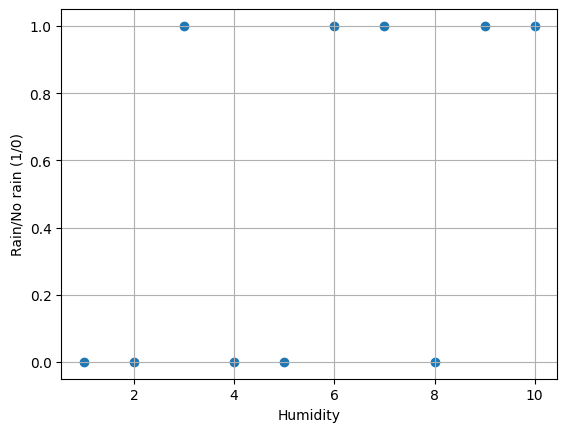

In [4]:
#show data
x = data[:,0]
y = data[:,1]
plt.scatter(x,y)
plt.grid()
plt.xlabel('Humidity')
plt.ylabel('Rain/No rain (1/0)')
plt.show()

In [ ]:
"""
# Q1 Demo conceptual pre-question
# Link function (logit function)
def logit(p):
    return np.log(p / (1 - p))

# Inverse link function (sigmoid function)
# ensure p_i between 0~1
def sigmoid(eta):
    return 1 / (1 + np.exp(-eta))
"""

In [5]:
def likelihood(theta, *args):
    b0 = theta[0]
    b1 = theta[1]
    eta = b0 +b1*x #here eta is unbounded
    #Q2 Express pi in terms of the link function
    #ensure p_i between 0~1
    pi = 1/(1 + np.exp(-eta))
    #Q3 implements the Bernoulli log-likelihood function
    return -np.sum(y*np.log(pi) + (1-y)*np.log(1-pi))

In [6]:
#Q4: Maximize the log-likelihood and estimate the parameters
theta0 = [1,1]
results = minimize(likelihood,theta0,args=(x,y),method='BFGS')
b0_opt = results.x[0]
b1_opt = results.x[1]
print(b0_opt, b1_opt)

-2.441288434136818 0.443870550218271


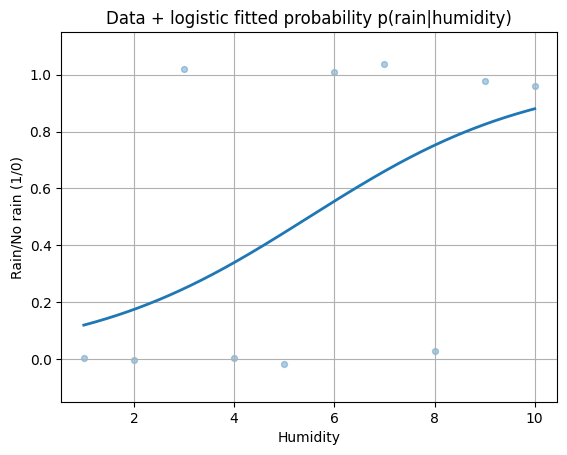

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# === helper ===
def sigmoid(z):
    return 1/(1+np.exp(-z))

# === 1) Scatter (with small jitter) + fitted probability curve ===
x = np.asarray(x, dtype=float)
y = np.asarray(y, dtype=float)

x_grid = np.linspace(x.min(), x.max(), 400)
p_grid = sigmoid(b0_opt + b1_opt * x_grid)

rng = np.random.default_rng(0)
y_jitter = y + rng.normal(0, 0.03, size=len(y))  # tiny jitter only for visibility

plt.figure()
plt.scatter(x, y_jitter, alpha=0.35, s=18)
plt.plot(x_grid, p_grid, linewidth=2)
plt.ylim(-0.15, 1.15)
plt.grid()
plt.xlabel("Humidity")
plt.ylabel("Rain/No rain (1/0)")
plt.title("Data + logistic fitted probability p(rain|humidity)")
plt.show()


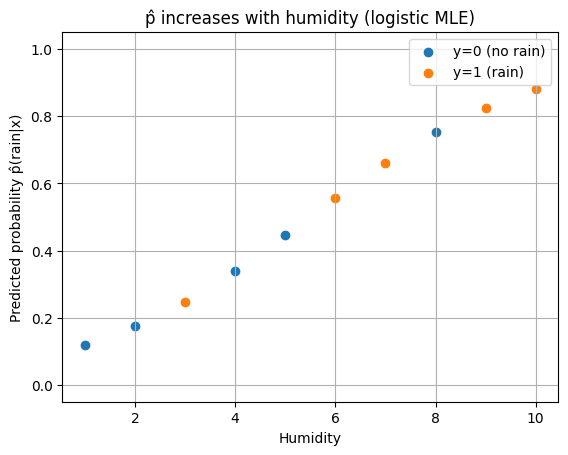

In [11]:
import numpy as np
import matplotlib.pyplot as plt

p_hat = 1/(1+np.exp(-(b0_opt + b1_opt*x)))

plt.figure()
plt.scatter(x[y==0], p_hat[y==0], label="y=0 (no rain)")
plt.scatter(x[y==1], p_hat[y==1], label="y=1 (rain)")
plt.grid()
plt.xlabel("Humidity")
plt.ylabel("Predicted probability p̂(rain|x)")
plt.title("p̂ increases with humidity (logistic MLE)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()


### **Q5: Put a Normal Prior on Parameters and Estimate the Posterior using MCMC**

#### **1. Prior Distribution**
Normal priors are set for $ b_0 $ and $ b_1 $:

$$
b_0 \sim \mathcal{N}(0, 4^2), \quad b_1 \sim \mathcal{N}(0, 2^2).
$$

#### **2. Likelihood Function**
A **Bernoulli likelihood function** is used:

$$
y_i \sim \text{Bernoulli}(p_i), \quad p_i = \frac{1}{1 + e^{-\eta_i}}.
$$

#### **3. Posterior Estimation**
The posterior distribution is estimated using **Markov Chain Monte Carlo (MCMC) sampling** with PyMC.


Output()

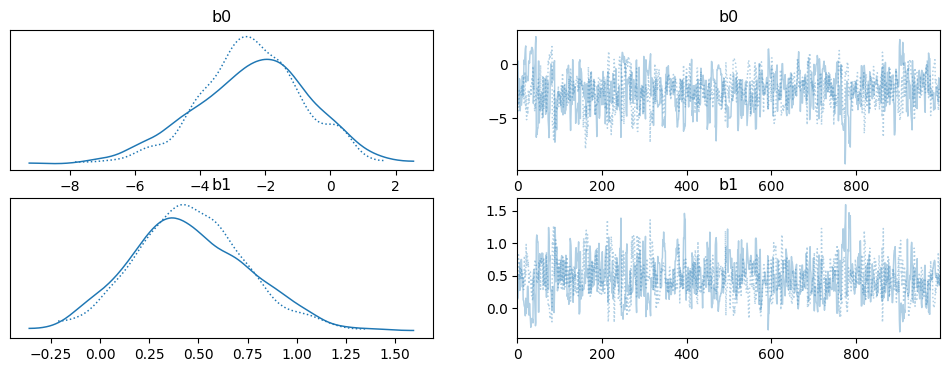

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b0,-2.408,1.666,-5.652,0.593,0.078,0.067,444.0,501.0,1.01
b1,0.461,0.293,-0.058,1.054,0.014,0.011,422.0,407.0,1.01


In [12]:
#Q5: Put a normal prior on parameters and estimate the posterior using MCMC
#arbitrary choices.
#better be based on reasonable assumptions
sigma_prior_b0 = 4 # sigma in prior distribution
sigma_prior_b1 = 2 # sigma in prior distribution
base_model = pm.Model()
with base_model:
    b0 = pm.Normal('b0',0,sigma=sigma_prior_b0)
    b1 = pm.Normal('b1',0,sigma=sigma_prior_b1)
    eta = b0 + b1*x
    pi = 1/(1 + np.exp(-eta)) #Expressing p_i in terms of the link function
    likelihood = pm.Bernoulli('y',p = pi, observed = y)
    trace = pm.sample(1000)
    #The posterior distributions of b0 and b1 are the answer of Q5
pm.plot_trace(trace)
plt.show()

pm.summary(trace)

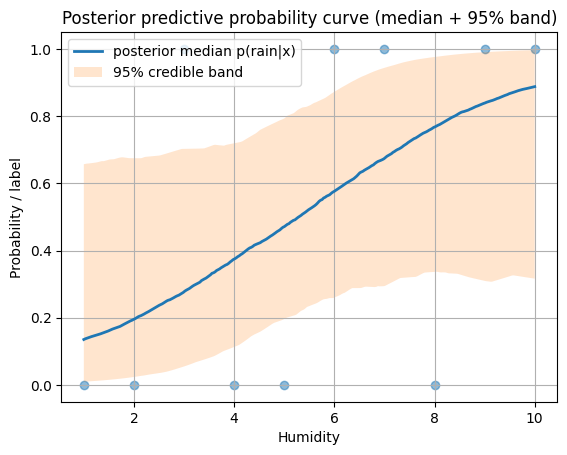

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x_grid = np.linspace(x.min(), x.max(), 300)

# InferenceData -> posterior
b0_s = trace.posterior["b0"].values.reshape(-1)
b1_s = trace.posterior["b1"].values.reshape(-1)

rng = np.random.default_rng(0)
M = min(500, len(b0_s))
idx = rng.choice(len(b0_s), size=M, replace=False)

p_samps = 1/(1 + np.exp(-(b0_s[idx,None] + b1_s[idx,None]*x_grid[None,:])))

p_med = np.median(p_samps, axis=0)
p_lo  = np.quantile(p_samps, 0.025, axis=0)
p_hi  = np.quantile(p_samps, 0.975, axis=0)

plt.figure()
plt.scatter(x, y, alpha=0.5)
plt.plot(x_grid, p_med, linewidth=2, label="posterior median p(rain|x)")
plt.fill_between(x_grid, p_lo, p_hi, alpha=0.2, label="95% credible band")
plt.ylim(-0.05, 1.05)
plt.grid()
plt.xlabel("Humidity")
plt.ylabel("Probability / label")
plt.title("Posterior predictive probability curve (median + 95% band)")
plt.legend()
plt.show()


# Sigmoid and Logit Functions

## **1. Sigmoid Function (Inverse Logit)**
The **sigmoid function** (also called the logistic function) is used to map any real-valued number $ \eta $ into the range $ (0,1) $, making it useful for probability estimation in logistic regression:

$$
p = \frac{1}{1 + e^{-\eta}}
$$

- When $ \eta = 0 $, then $ p = 0.5 $.
- As $ \eta \to +\infty $, $ p \to 1 $.
- As $ \eta \to -\infty $, $ p \to 0 $.

## **2. Logit Function (Inverse of Sigmoid)**
The **logit function** is the inverse of the sigmoid function. It transforms a probability $ p $ (which is bounded between 0 and 1) into an unbounded real number $ \eta $:

$$
\eta = \log\left(\frac{p}{1 - p}\right)
$$

- When $ p = 0.5 $, then $ \eta = 0 $.
- As $ p \to 1 $, $ \eta \to +\infty $.
- As $ p \to 0 $, $ \eta \to -\infty $.

## **3. Relationship Between Sigmoid and Logit**
Since the logit function is the inverse of the sigmoid function, applying one after the other recovers the original value:

$$
\text{logit}(\text{sigmoid}(\eta)) = \eta, \quad \text{and} \quad \text{sigmoid}(\text{logit}(p)) = p.
$$

These functions are essential in **logistic regression**, where we assume a linear relationship between the predictor $ x $ and the logit $ \eta $, and then use the sigmoid function to obtain probabilities.


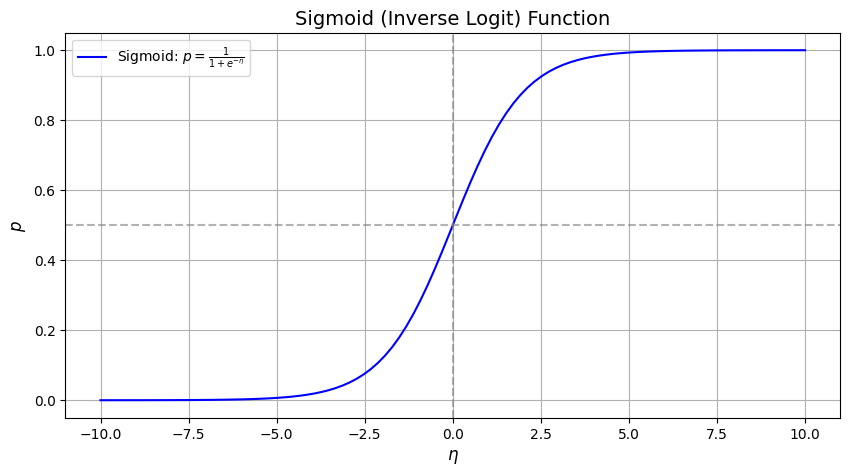

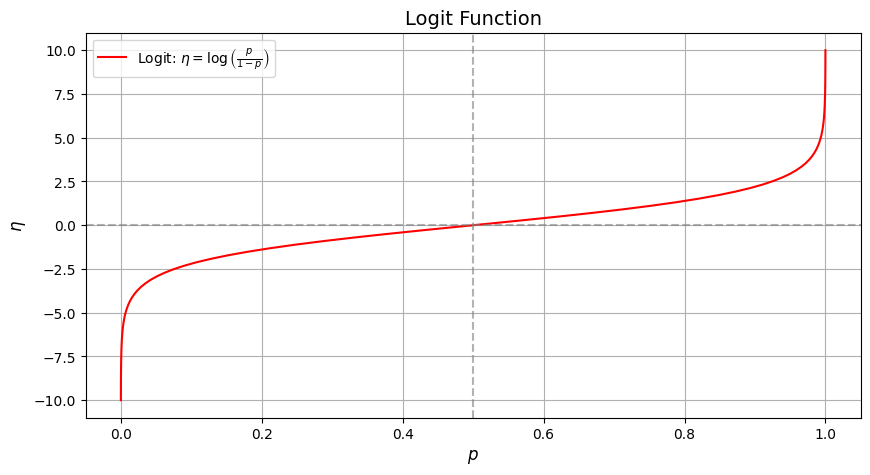

In [ ]:
# Define a range of values for eta (logit function input)
eta = np.linspace(-10, 10, 100)

# Compute sigmoid (inverse logit) function
sigmoid = 1 / (1 + np.exp(-eta))

# Compute logit function (log-odds) avoiding division by zero
logit = np.log(sigmoid / (1 - sigmoid))

# Plot sigmoid function: converts an unbounded real number into probabilities (0~1)
plt.figure(figsize=(10, 5))
plt.plot(eta, sigmoid, label=r'Sigmoid: $p = \frac{1}{1 + e^{-\eta}}$', color='blue')
plt.xlabel(r'$\eta$', fontsize=12)
plt.ylabel(r'$p$', fontsize=12)
plt.title("Sigmoid (Inverse Logit) Function", fontsize=14)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', alpha=0.6)
plt.legend()
plt.grid()
plt.show()

# Plot logit function: converts probabilities (0~1) into an unbounded real number
plt.figure(figsize=(10, 5))
plt.plot(sigmoid, logit, label=r'Logit: $\eta = \log\left(\frac{p}{1 - p}\right)$', color='red')
plt.xlabel(r'$p$', fontsize=12)
plt.ylabel(r'$\eta$', fontsize=12)
plt.title("Logit Function", fontsize=14)
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.axvline(0.5, color='gray', linestyle='--', alpha=0.6)
plt.legend()
plt.grid()
plt.show()
